Using device: cuda

MAP metrics
mnist_conf: 0.9950
mnist_nll: 0.0454
mnist_acc: 0.9887
mnist_ece: 0.0065
mnist_mce: 0.2477
mnist_brier: 0.0186
fmnist_conf: 0.8666
auroc: 0.9331

Top-k=0.05, alpha=1e-05
mnist_conf: 0.8019
mnist_nll: 0.2694
mnist_acc: 0.9658
mnist_ece: 0.1639
mnist_mce: 0.3325
mnist_brier: 0.1083
fmnist_conf: 0.4750
auroc: 0.8917

Top-k=0.05, alpha=0.0001
mnist_conf: 0.9779
mnist_nll: 0.0424
mnist_acc: 0.9889
mnist_ece: 0.0110
mnist_mce: 0.2215
mnist_brier: 0.0193
fmnist_conf: 0.6977
auroc: 0.9431

Top-k=0.05, alpha=0.001
mnist_conf: 0.9918
mnist_nll: 0.0389
mnist_acc: 0.9887
mnist_ece: 0.0038
mnist_mce: 0.2043
mnist_brier: 0.0174
fmnist_conf: 0.7794
auroc: 0.9600

Top-k=0.2, alpha=1e-05
mnist_conf: 0.6804
mnist_nll: 0.4545
mnist_acc: 0.9451
mnist_ece: 0.2648
mnist_mce: 0.3995
mnist_brier: 0.1958
fmnist_conf: 0.4877
auroc: 0.7917

Top-k=0.2, alpha=0.0001
mnist_conf: 0.9709
mnist_nll: 0.0507
mnist_acc: 0.9865
mnist_ece: 0.0156
mnist_mce: 0.1828
mnist_brier: 0.0233
fmnist_

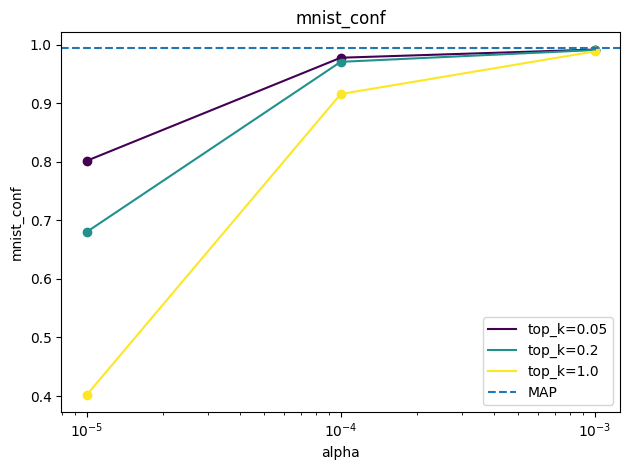

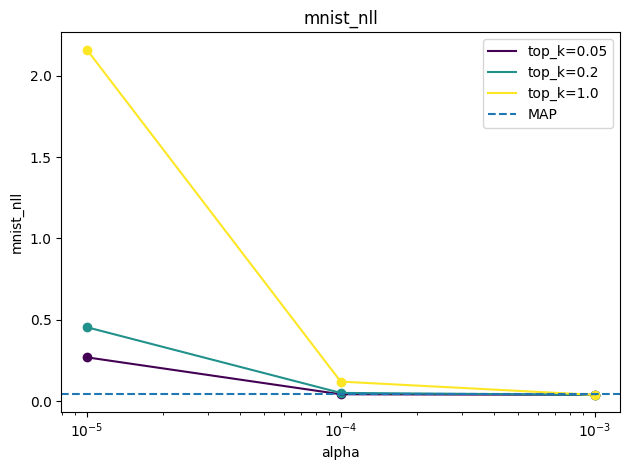

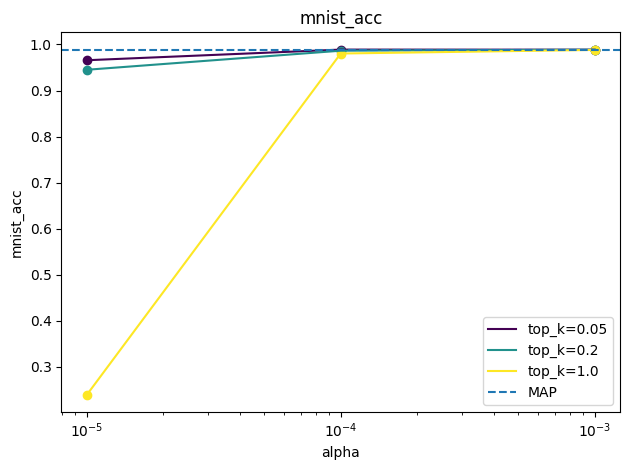

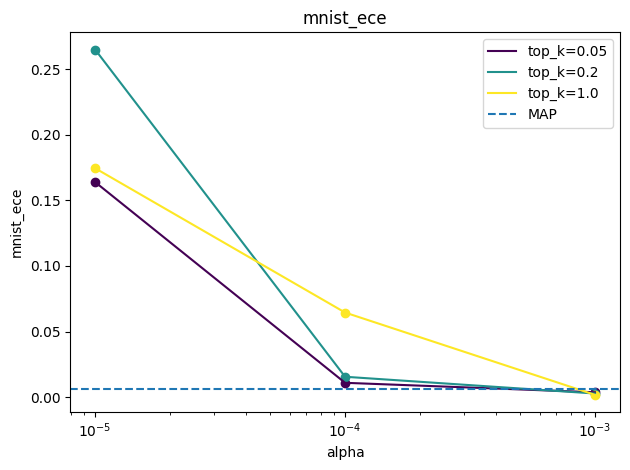

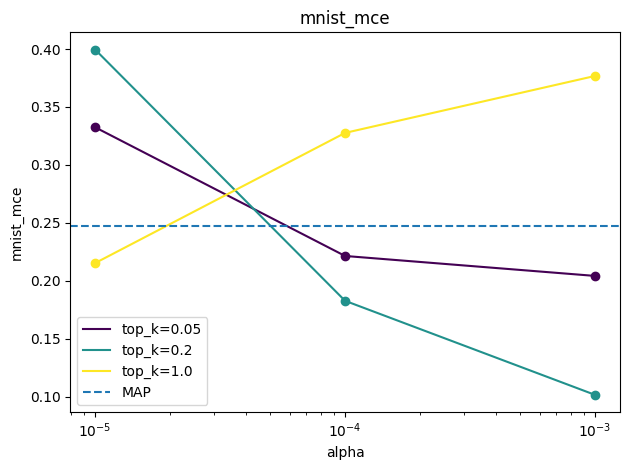

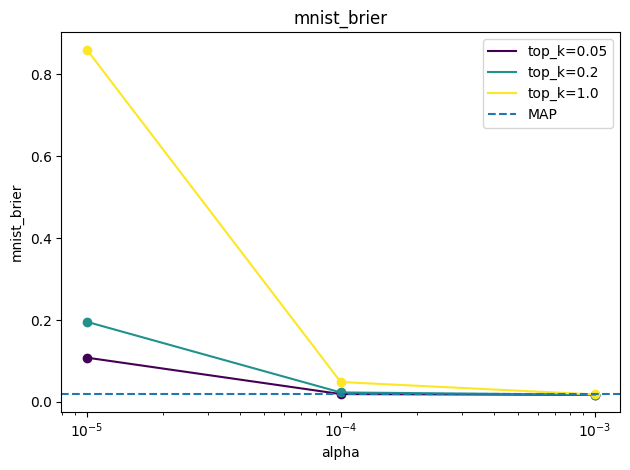

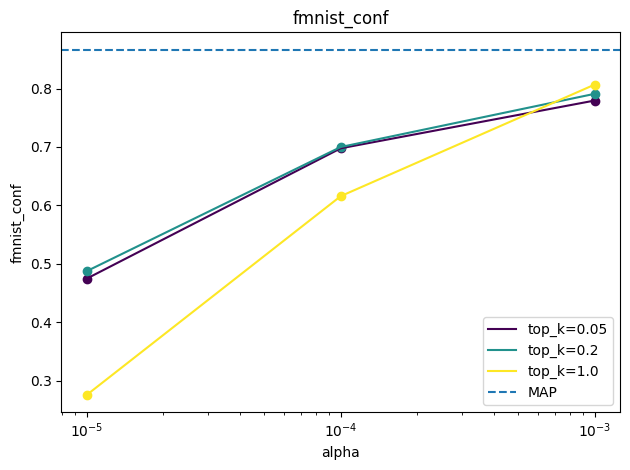

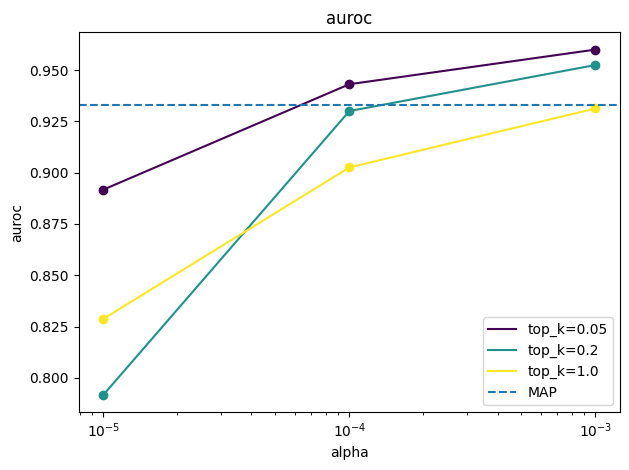

In [1]:
import torch
import torch.nn.functional as F
from torch.func import functional_call, vmap
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from mnist import get_mnist_loaders, get_fmnist_loaders
from LeNet import LeNet
import redux_utils

# =========================
# Calibration / Brier
# =========================

def get_calib(pys, y_true, M=10):
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)

    preds = np.argmax(pys, axis=1)
    confs = np.max(pys, axis=1)

    bin_boundaries = np.linspace(0, 1, M + 1)
    conf_idxs = np.digitize(confs, bin_boundaries, right=True) - 1
    conf_idxs = np.clip(conf_idxs, 0, M - 1)

    accs_bin, confs_bin, nitems_bin = [], [], []

    for i in range(M):
        in_bin = (conf_idxs == i)
        n_in_bin = np.sum(in_bin)

        if n_in_bin > 0:
            bin_acc = np.mean(preds[in_bin] == y_true[in_bin])
            bin_conf = np.mean(confs[in_bin])

            accs_bin.append(bin_acc)
            confs_bin.append(bin_conf)
            nitems_bin.append(n_in_bin)

    if not accs_bin:
        return 0.0, 0.0

    accs_bin = np.array(accs_bin)
    confs_bin = np.array(confs_bin)
    nitems_bin = np.array(nitems_bin)

    gaps = np.abs(accs_bin - confs_bin)
    weights = nitems_bin / np.sum(nitems_bin)

    ECE = np.sum(gaps * weights)
    MCE = np.max(gaps)

    return ECE, MCE


def get_brier_score(probs, y_true):
    return np.mean(np.sum((probs - y_true) ** 2, axis=1))


# =========================
# Param utils
# =========================

def make_functional(model):
    params = dict(model.named_parameters())
    buffers = dict(model.named_buffers())
    return params, buffers


def stack_params(param_list):
    return {k: torch.stack([p[k] for p in param_list]) for k in param_list[0]}


def load_param_dicts(paths, model, device):
    param_list = []

    for p in paths:
        state = torch.load(p, map_location=device)
        model.load_state_dict(state)

        params, _ = make_functional(model)
        param_list.append({k: v.detach().clone() for k, v in params.items()})

    return stack_params(param_list)


# =========================
# Forward abstraction
# =========================

def make_forward(model, params):
    buffers = dict(model.named_buffers())
    example_param = next(iter(params.values()))

    # MAP
    if example_param.dim() == len(model.state_dict()[next(iter(params))].shape):
        def forward(x):
            return functional_call(model, (params, buffers), (x,))
        return forward, False

    # Ensemble
    def fmodel(p, x):
        return functional_call(model, (p, buffers), (x,))

    def forward(x):
        return vmap(fmodel, in_dims=(0, None))(params, x)

    return forward, True


# =========================
# MNIST metrics
# =========================

def mnist_metrics(model, params, loader, device, num_classes=10):
    forward, is_ensemble = make_forward(model, params)

    all_probs = []
    all_labels = []

    total_nll = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = forward(x)

            if is_ensemble:
                probs = torch.softmax(logits, dim=-1).mean(dim=0)

                log_probs = torch.logsumexp(
                    F.log_softmax(logits, dim=-1), dim=0
                ) - torch.log(torch.tensor(logits.shape[0], device=device))

                nll = F.nll_loss(log_probs, y, reduction='sum')
            else:
                probs = torch.softmax(logits, dim=-1)
                nll = F.cross_entropy(logits, y, reduction='sum')

            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

            total_nll += nll.item()
            total += y.size(0)

    probs = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_onehot = np.eye(num_classes)[y_true]

    preds = np.argmax(probs, axis=1)

    acc = np.mean(preds == y_true)
    conf = np.mean(np.max(probs, axis=1))
    nll = total_nll / total

    ece, mce = get_calib(probs, y_onehot)
    brier = get_brier_score(probs, y_onehot)

    return conf, nll, acc, ece, mce, brier


# =========================
# FMNIST confidence
# =========================

def fmnist_conf(model, params, loader, device):
    forward, is_ensemble = make_forward(model, params)

    conf_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            logits = forward(x)

            if is_ensemble:
                probs = torch.softmax(logits, dim=-1).mean(dim=0)
            else:
                probs = torch.softmax(logits, dim=-1)

            conf_sum += probs.max(dim=-1).values.mean().item()
            n_batches += 1

    return conf_sum / n_batches


# =========================
# OOD AUROC
# =========================

def ood_auroc(model, params, mnist_loader, fmnist_loader, device):
    forward, is_ensemble = make_forward(model, params)

    scores = []
    labels = []

    with torch.no_grad():
        for x, _ in mnist_loader:
            x = x.to(device)

            logits = forward(x)
            probs = torch.softmax(logits, dim=-1)
            if is_ensemble:
                probs = probs.mean(dim=0)

            conf = probs.max(dim=-1).values

            scores.append((1 - conf).cpu())
            labels.append(torch.zeros(len(conf)))

        for x, _ in fmnist_loader:
            x = x.to(device)

            logits = forward(x)
            probs = torch.softmax(logits, dim=-1)
            if is_ensemble:
                probs = probs.mean(dim=0)

            conf = probs.max(dim=-1).values

            scores.append((1 - conf).cpu())
            labels.append(torch.ones(len(conf)))

    scores = torch.cat(scores).numpy()
    labels = torch.cat(labels).numpy()

    return roc_auc_score(labels, scores)


# =========================
# Unified evaluation
# =========================

def evaluate_all(model, params, mnist_loader, fmnist_loader, device):
    mnist_conf, nll, acc, ece, mce, brier = mnist_metrics(
        model, params, mnist_loader, device
    )

    f_conf = fmnist_conf(model, params, fmnist_loader, device)

    auroc = ood_auroc(model, params, mnist_loader, fmnist_loader, device)

    return {
        "mnist_conf": mnist_conf,
        "mnist_nll": nll,
        "mnist_acc": acc,
        "mnist_ece": ece,
        "mnist_mce": mce,
        "mnist_brier": brier,
        "fmnist_conf": f_conf,
        "auroc": auroc,
    }


# =========================
# Plotting
# =========================

def plot_metrics(results, map_metrics, alphas, top_ks):
    metrics_names = list(map_metrics.keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_ks)))

    for metric in metrics_names:
        plt.figure()

        for i, top_k in enumerate(top_ks):
            ys = [results[top_k][alpha][metric] for alpha in alphas]

            plt.plot(alphas, ys, label=f"top_k={top_k}", color=colors[i])
            plt.scatter(alphas, ys, color=colors[i])

        plt.axhline(map_metrics[metric], linestyle='--', label='MAP')

        plt.xscale("log")
        plt.xlabel("alpha")
        plt.ylabel(metric)
        plt.title(metric)

        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================
# Main
# =========================

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    _, mnist_loader = get_mnist_loaders(test_batch_size=10000)
    _, fmnist_loader = get_fmnist_loaders(test_batch_size=10000)

    model = LeNet(activation="tanh").to(device)

    # MAP
    model.load_state_dict(torch.load("adam_map.pth", map_location=device))
    params, _ = make_functional(model)

    map_metrics = evaluate_all(model, params, mnist_loader, fmnist_loader, device)

    print("\nMAP metrics")
    for k, v in map_metrics.items():
        print(f"{k}: {v:.4f}")

    # Sweep
    top_ks = [0.05, 0.2, 1.0]
    alphas = [1e-5, 1e-4, 1e-3]

    results = {top_k: {} for top_k in top_ks}

    for top_k in top_ks:
        for alph in alphas:
            print(f"\nTop-k={top_k}, alpha={alph}")

            paths = [
                f"adam_samples/top_k{top_k}alpha_{alph}_samp{i+1}.pth"
                for i in range(10)
            ]

            stacked_params = load_param_dicts(paths, model, device)

            metrics = evaluate_all(
                model,
                stacked_params,
                mnist_loader,
                fmnist_loader,
                device,
            )

            results[top_k][alph] = metrics

            for k, v in metrics.items():
                print(f"{k}: {v:.4f}")

    # Plot
    plot_metrics(results, map_metrics, alphas, top_ks)


if __name__ == "__main__":
    main()

Using device: cuda

MAP metrics
mnist_conf: 0.9950
mnist_nll: 0.0454
mnist_acc: 0.9887
mnist_ece: 0.0065
mnist_mce: 0.2477
mnist_brier: 0.0186
fmnist_conf: 0.8666
auroc: 0.9331

Top-k=0.05, alpha=1e-06
mnist_conf: 0.5054
mnist_nll: 0.8191
mnist_acc: 0.8535
mnist_ece: 0.3481
mnist_mce: 0.4410
mnist_brier: 0.3818
fmnist_conf: 0.3915
auroc: 0.6974

Top-k=0.05, alpha=1e-05
mnist_conf: 0.8019
mnist_nll: 0.2694
mnist_acc: 0.9658
mnist_ece: 0.1639
mnist_mce: 0.3325
mnist_brier: 0.1083
fmnist_conf: 0.4750
auroc: 0.8917

Top-k=0.05, alpha=0.0001
mnist_conf: 0.9779
mnist_nll: 0.0424
mnist_acc: 0.9889
mnist_ece: 0.0110
mnist_mce: 0.2215
mnist_brier: 0.0193
fmnist_conf: 0.6977
auroc: 0.9431

Top-k=0.05, alpha=0.001
mnist_conf: 0.9918
mnist_nll: 0.0389
mnist_acc: 0.9887
mnist_ece: 0.0038
mnist_mce: 0.2043
mnist_brier: 0.0174
fmnist_conf: 0.7794
auroc: 0.9600

Top-k=0.05, alpha=0.01
mnist_conf: 0.9947
mnist_nll: 0.0443
mnist_acc: 0.9889
mnist_ece: 0.0067
mnist_mce: 0.3820
mnist_brier: 0.0184
fmnist_

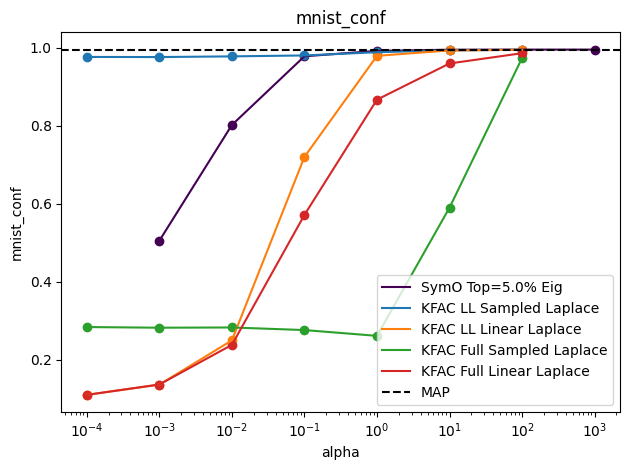

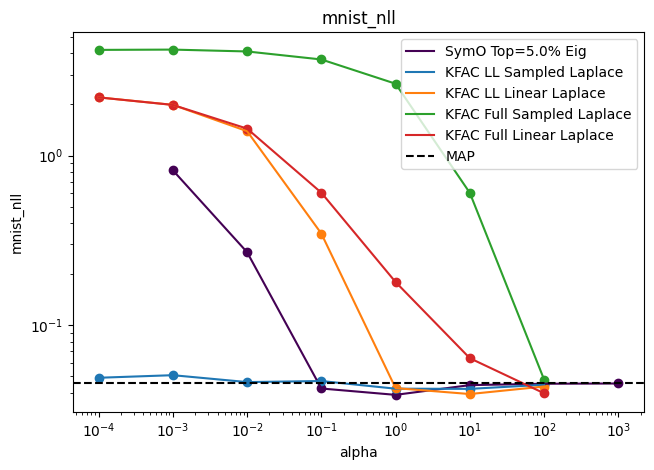

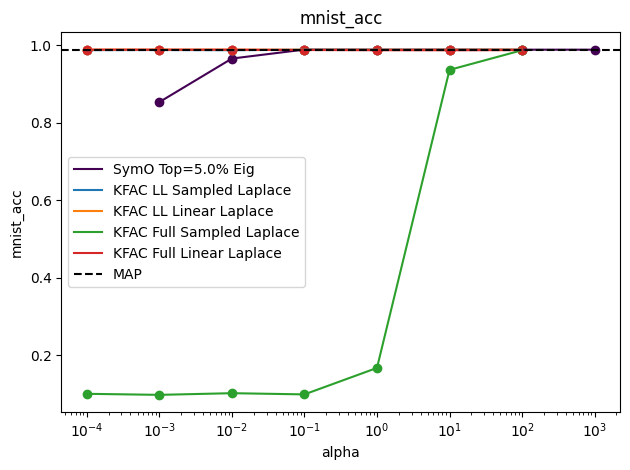

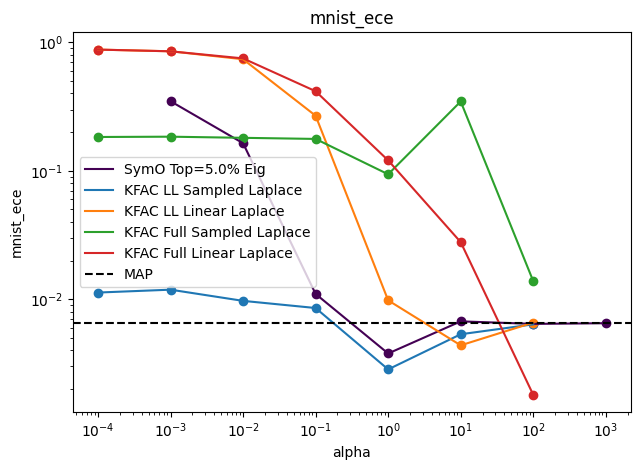

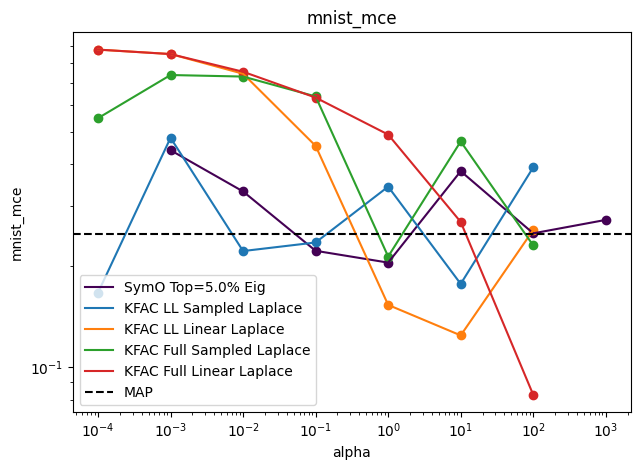

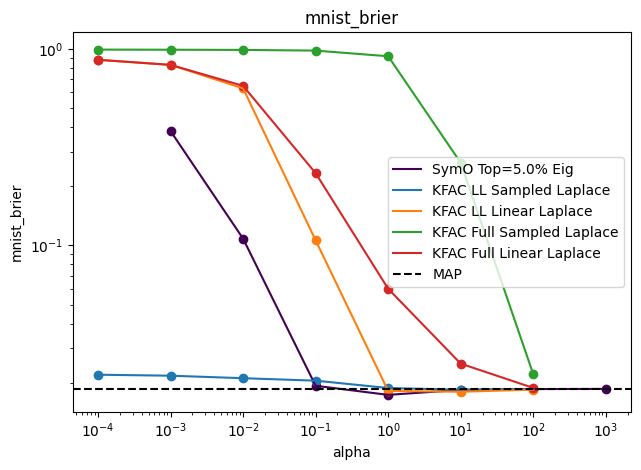

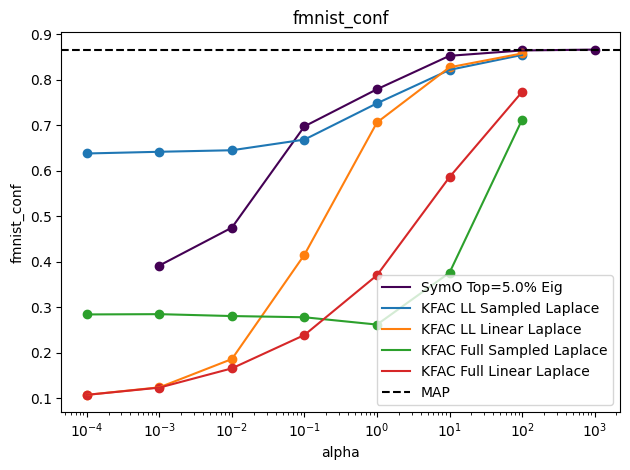

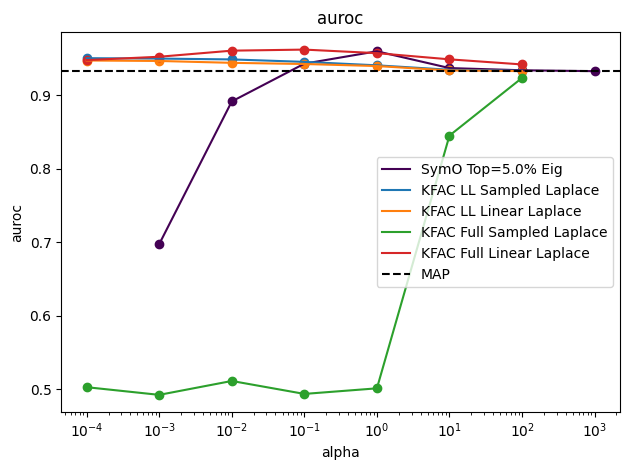

In [2]:
import torch
import torch.nn.functional as F
from torch.func import functional_call, vmap
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from mnist import get_mnist_loaders, get_fmnist_loaders
from LeNet import LeNet


# =========================
# Calibration / Brier
# =========================

def get_calib(pys, y_true, M=10):
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)

    preds = np.argmax(pys, axis=1)
    confs = np.max(pys, axis=1)

    bin_boundaries = np.linspace(0, 1, M + 1)
    conf_idxs = np.digitize(confs, bin_boundaries, right=True) - 1
    conf_idxs = np.clip(conf_idxs, 0, M - 1)

    accs_bin, confs_bin, nitems_bin = [], [], []

    for i in range(M):
        in_bin = (conf_idxs == i)
        n_in_bin = np.sum(in_bin)

        if n_in_bin > 0:
            bin_acc = np.mean(preds[in_bin] == y_true[in_bin])
            bin_conf = np.mean(confs[in_bin])

            accs_bin.append(bin_acc)
            confs_bin.append(bin_conf)
            nitems_bin.append(n_in_bin)

    if not accs_bin:
        return 0.0, 0.0

    accs_bin = np.array(accs_bin)
    confs_bin = np.array(confs_bin)
    nitems_bin = np.array(nitems_bin)

    gaps = np.abs(accs_bin - confs_bin)
    weights = nitems_bin / np.sum(nitems_bin)

    ECE = np.sum(gaps * weights)
    MCE = np.max(gaps)

    return ECE, MCE


def get_brier_score(probs, y_true):
    return np.mean(np.sum((probs - y_true) ** 2, axis=1))


# =========================
# Param utils
# =========================

def make_functional(model):
    params = dict(model.named_parameters())
    buffers = dict(model.named_buffers())
    return params, buffers


def stack_params(param_list):
    return {k: torch.stack([p[k] for p in param_list]) for k in param_list[0]}


def load_param_dicts(paths, model, device):
    param_list = []

    for p in paths:
        state = torch.load(p, map_location=device)
        model.load_state_dict(state)

        params, _ = make_functional(model)
        param_list.append({k: v.detach().clone() for k, v in params.items()})

    return stack_params(param_list)


# =========================
# Forward abstraction
# =========================

def make_forward(model, params):
    buffers = dict(model.named_buffers())
    example_param = next(iter(params.values()))

    # MAP
    if example_param.dim() == len(model.state_dict()[next(iter(params))].shape):
        def forward(x):
            return functional_call(model, (params, buffers), (x,))
        return forward, False

    # Ensemble
    def fmodel(p, x):
        return functional_call(model, (p, buffers), (x,))

    def forward(x):
        return vmap(fmodel, in_dims=(0, None))(params, x)

    return forward, True


# =========================
# MNIST metrics
# =========================

def mnist_metrics(model, params, loader, device, num_classes=10):
    forward, is_ensemble = make_forward(model, params)

    all_probs = []
    all_labels = []

    total_nll = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = forward(x)

            if is_ensemble:
                probs = torch.softmax(logits, dim=-1).mean(dim=0)

                log_probs = torch.logsumexp(
                    F.log_softmax(logits, dim=-1), dim=0
                ) - torch.log(torch.tensor(logits.shape[0], device=device))

                nll = F.nll_loss(log_probs, y, reduction='sum')
            else:
                probs = torch.softmax(logits, dim=-1)
                nll = F.cross_entropy(logits, y, reduction='sum')

            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

            total_nll += nll.item()
            total += y.size(0)

    probs = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_onehot = np.eye(num_classes)[y_true]

    preds = np.argmax(probs, axis=1)

    acc = np.mean(preds == y_true)
    conf = np.mean(np.max(probs, axis=1))
    nll = total_nll / total

    ece, mce = get_calib(probs, y_onehot)
    brier = get_brier_score(probs, y_onehot)

    return conf, nll, acc, ece, mce, brier


# =========================
# FMNIST confidence
# =========================

def fmnist_conf(model, params, loader, device):
    forward, is_ensemble = make_forward(model, params)

    conf_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            logits = forward(x)

            if is_ensemble:
                probs = torch.softmax(logits, dim=-1).mean(dim=0)
            else:
                probs = torch.softmax(logits, dim=-1)

            conf_sum += probs.max(dim=-1).values.mean().item()
            n_batches += 1

    return conf_sum / n_batches


# =========================
# OOD AUROC
# =========================

def ood_auroc(model, params, mnist_loader, fmnist_loader, device):
    forward, is_ensemble = make_forward(model, params)

    scores = []
    labels = []

    with torch.no_grad():
        for x, _ in mnist_loader:
            x = x.to(device)

            logits = forward(x)
            probs = torch.softmax(logits, dim=-1)
            if is_ensemble:
                probs = probs.mean(dim=0)

            conf = probs.max(dim=-1).values

            scores.append((1 - conf).cpu())
            labels.append(torch.zeros(len(conf)))

        for x, _ in fmnist_loader:
            x = x.to(device)

            logits = forward(x)
            probs = torch.softmax(logits, dim=-1)
            if is_ensemble:
                probs = probs.mean(dim=0)

            conf = probs.max(dim=-1).values

            scores.append((1 - conf).cpu())
            labels.append(torch.ones(len(conf)))

    scores = torch.cat(scores).numpy()
    labels = torch.cat(labels).numpy()

    return roc_auc_score(labels, scores)


# =========================
# Unified evaluation
# =========================

def evaluate_all(model, params, mnist_loader, fmnist_loader, device):
    mnist_conf, nll, acc, ece, mce, brier = mnist_metrics(
        model, params, mnist_loader, device
    )

    f_conf = fmnist_conf(model, params, fmnist_loader, device)

    auroc = ood_auroc(model, params, mnist_loader, fmnist_loader, device)

    return {
        "mnist_conf": mnist_conf,
        "mnist_nll": nll,
        "mnist_acc": acc,
        "mnist_ece": ece,
        "mnist_mce": mce,
        "mnist_brier": brier,
        "fmnist_conf": f_conf,
        "auroc": auroc,
    }


# =========================
# Plotting
# =========================

def plot_metrics(results, map_metrics, alphas, top_ks):
    metrics_names = list(map_metrics.keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_ks)))
    redux_prec = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

    shift = 1e3

    for metric in metrics_names:
        samp_ll_kron = redux_utils.get_redux_stats(metric,redux_prec,'kron','samp',subnet='last_layer')
        lin_ll_kron = redux_utils.get_redux_stats(metric,redux_prec,'kron','linear',subnet='last_layer')

        samp_all_kron = redux_utils.get_redux_stats(metric,redux_prec,'kron','samp',subnet='all')
        lin_all_kron = redux_utils.get_redux_stats(metric,redux_prec,'kron','linear',subnet='all')


        plt.figure()



        for i, top_k in enumerate(top_ks):
            ys = [results[top_k][alpha][metric] for alpha in alphas]

            plt.plot(np.array(alphas)*shift, ys, label=f"SymO Top={top_k*100}% Eig", color=colors[i])
            plt.scatter(np.array(alphas)*shift, ys, color=colors[i])

        plt.plot(redux_prec,samp_ll_kron,label='KFAC LL Sampled Laplace')
        plt.scatter(redux_prec,samp_ll_kron)

        plt.plot(redux_prec,lin_ll_kron,label='KFAC LL Linear Laplace')
        plt.scatter(redux_prec,lin_ll_kron)

        plt.plot(redux_prec,samp_all_kron,label='KFAC Full Sampled Laplace')
        plt.scatter(redux_prec,samp_all_kron)

        plt.plot(redux_prec,lin_all_kron,label='KFAC Full Linear Laplace')
        plt.scatter(redux_prec,lin_all_kron)

        plt.axhline(map_metrics[metric], linestyle='--', label='MAP',color='black')

        plt.xscale("log")
        plt.xlabel("alpha")
        plt.ylabel(metric)
        plt.title(metric)

        plt.legend()
        plt.tight_layout()
        if metric == 'mnist_ece' or metric == 'mnist_mce' or metric == 'mnist_nll' or metric == 'mnist_brier':
            plt.yscale('log')
        plt.show()


# =========================
# Main
# =========================

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    _, mnist_loader = get_mnist_loaders(test_batch_size=10000)
    _, fmnist_loader = get_fmnist_loaders(test_batch_size=10000)

    model = LeNet(activation="tanh").to(device)

    # MAP
    model.load_state_dict(torch.load("adam_map.pth", map_location=device))
    params, _ = make_functional(model)

    map_metrics = evaluate_all(model, params, mnist_loader, fmnist_loader, device)

    print("\nMAP metrics")
    for k, v in map_metrics.items():
        print(f"{k}: {v:.4f}")

    # Sweep
    top_ks = [0.05]
    alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

    results = {top_k: {} for top_k in top_ks}

    for top_k in top_ks:
        for alph in alphas:
            print(f"\nTop-k={top_k}, alpha={alph}")

            if alph in [1e-5,1e-4,1e-3]:
                paths = [
                f"adam_samples/top_k0.05alpha_{alph}_samp{i+1}.pth"
                for i in range(10)
            ]

            else:
                paths = [
                f"adam_samples/alpha_{alph}_samp{i+1}.pth"
                for i in range(10)
            ]

            stacked_params = load_param_dicts(paths, model, device)

            metrics = evaluate_all(
                model,
                stacked_params,
                mnist_loader,
                fmnist_loader,
                device,
            )

            results[top_k][alph] = metrics

            for k, v in metrics.items():
                print(f"{k}: {v:.4f}")


    # Plot
    plot_metrics(results, map_metrics, alphas, top_ks)


if __name__ == "__main__":
    main()

Using device: cuda

MAP metrics
mnist_conf: 0.9950
mnist_nll: 0.0454
mnist_acc: 0.9887
mnist_ece: 0.0065
mnist_mce: 0.2477
mnist_brier: 0.0186
fmnist_conf: 0.8666
auroc: 0.9331

Top-k=0.05, alpha=1e-05
mnist_conf: 0.8019
mnist_nll: 0.2694
mnist_acc: 0.9658
mnist_ece: 0.1639
mnist_mce: 0.3325
mnist_brier: 0.1083
fmnist_conf: 0.4750
auroc: 0.8917

Top-k=0.05, alpha=0.0001
mnist_conf: 0.9779
mnist_nll: 0.0424
mnist_acc: 0.9889
mnist_ece: 0.0110
mnist_mce: 0.2215
mnist_brier: 0.0193
fmnist_conf: 0.6977
auroc: 0.9431

Top-k=0.05, alpha=0.001
mnist_conf: 0.9918
mnist_nll: 0.0389
mnist_acc: 0.9887
mnist_ece: 0.0038
mnist_mce: 0.2043
mnist_brier: 0.0174
fmnist_conf: 0.7794
auroc: 0.9600

Top-k=0.2, alpha=1e-05
mnist_conf: 0.6804
mnist_nll: 0.4545
mnist_acc: 0.9451
mnist_ece: 0.2648
mnist_mce: 0.3995
mnist_brier: 0.1958
fmnist_conf: 0.4877
auroc: 0.7917

Top-k=0.2, alpha=0.0001
mnist_conf: 0.9709
mnist_nll: 0.0507
mnist_acc: 0.9865
mnist_ece: 0.0156
mnist_mce: 0.1828
mnist_brier: 0.0233
fmnist_

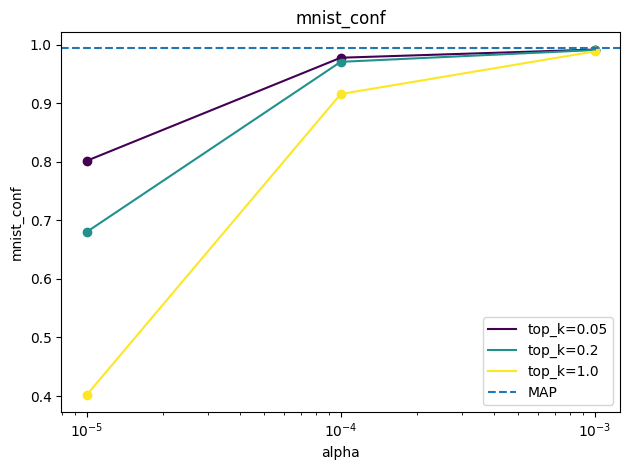

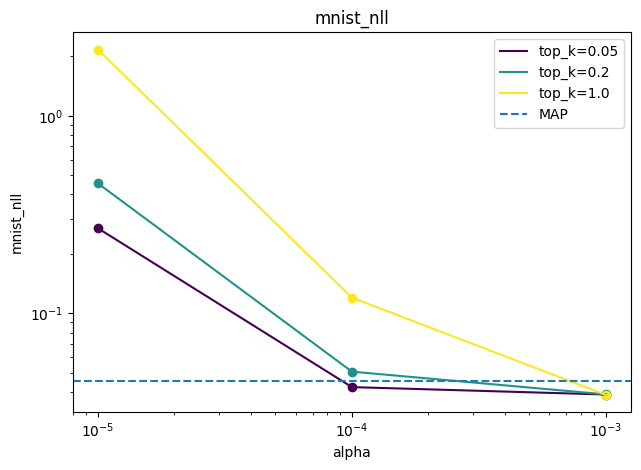

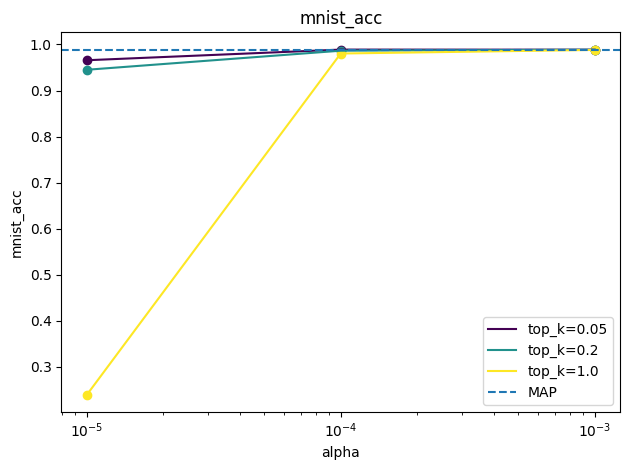

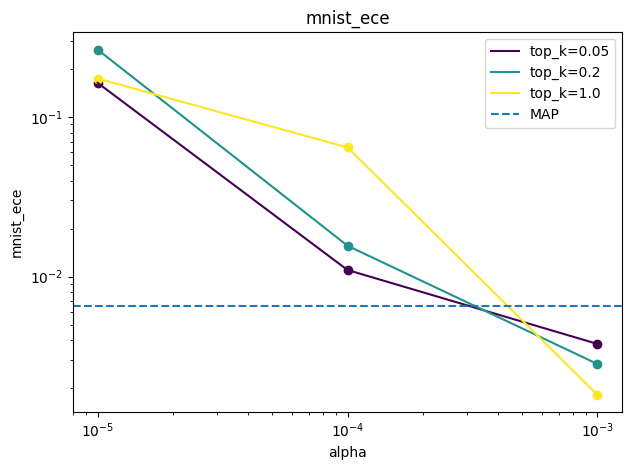

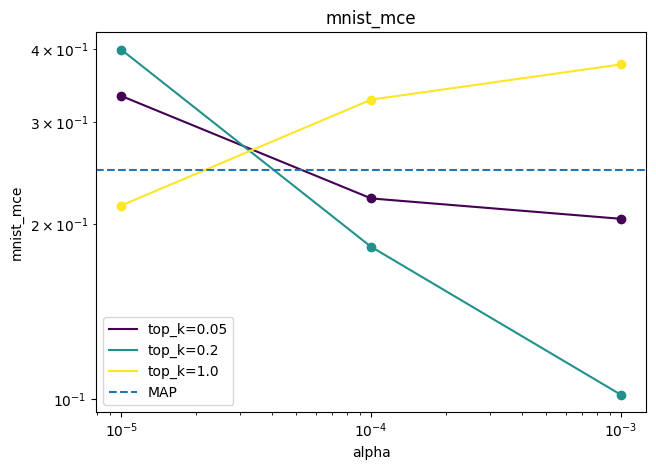

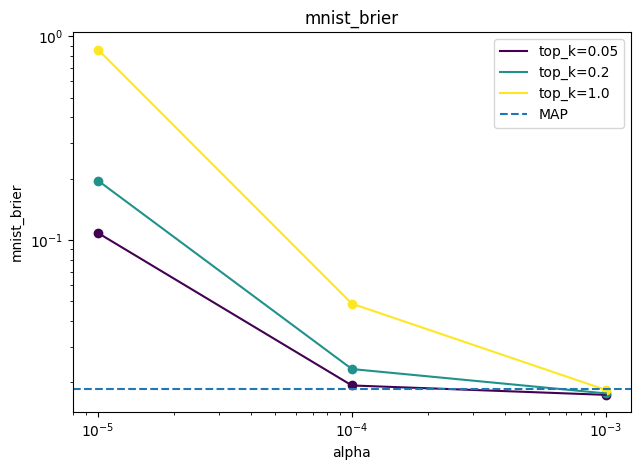

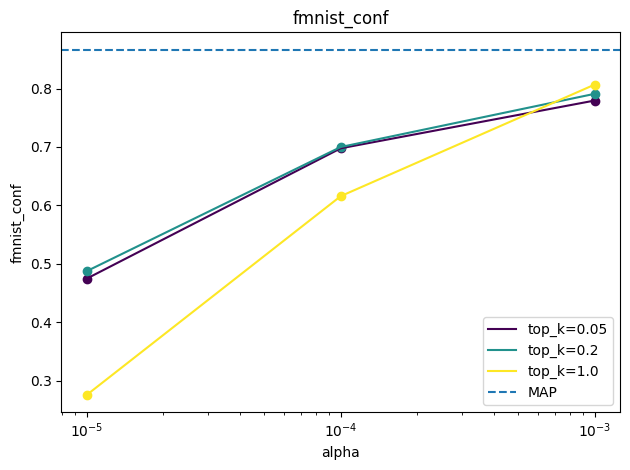

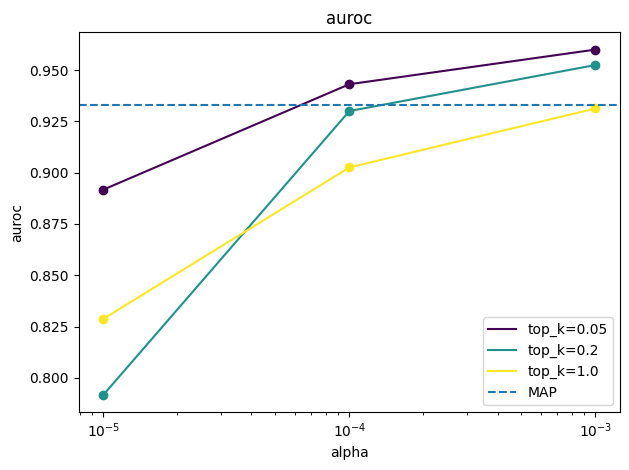

In [3]:
import torch
import torch.nn.functional as F
from torch.func import functional_call, vmap
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

from mnist import get_mnist_loaders, get_fmnist_loaders
from LeNet import LeNet


# =========================
# Calibration / Brier
# =========================

def get_calib(pys, y_true, M=10):
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)

    preds = np.argmax(pys, axis=1)
    confs = np.max(pys, axis=1)

    bin_boundaries = np.linspace(0, 1, M + 1)
    conf_idxs = np.digitize(confs, bin_boundaries, right=True) - 1
    conf_idxs = np.clip(conf_idxs, 0, M - 1)

    accs_bin, confs_bin, nitems_bin = [], [], []

    for i in range(M):
        in_bin = (conf_idxs == i)
        n_in_bin = np.sum(in_bin)

        if n_in_bin > 0:
            bin_acc = np.mean(preds[in_bin] == y_true[in_bin])
            bin_conf = np.mean(confs[in_bin])

            accs_bin.append(bin_acc)
            confs_bin.append(bin_conf)
            nitems_bin.append(n_in_bin)

    if not accs_bin:
        return 0.0, 0.0

    accs_bin = np.array(accs_bin)
    confs_bin = np.array(confs_bin)
    nitems_bin = np.array(nitems_bin)

    gaps = np.abs(accs_bin - confs_bin)
    weights = nitems_bin / np.sum(nitems_bin)

    ECE = np.sum(gaps * weights)
    MCE = np.max(gaps)

    return ECE, MCE


def get_brier_score(probs, y_true):
    return np.mean(np.sum((probs - y_true) ** 2, axis=1))


# =========================
# Param utils
# =========================

def make_functional(model):
    params = dict(model.named_parameters())
    buffers = dict(model.named_buffers())
    return params, buffers


def stack_params(param_list):
    return {k: torch.stack([p[k] for p in param_list]) for k in param_list[0]}


def load_param_dicts(paths, model, device):
    param_list = []

    for p in paths:
        state = torch.load(p, map_location=device)
        model.load_state_dict(state)

        params, _ = make_functional(model)
        param_list.append({k: v.detach().clone() for k, v in params.items()})

    return stack_params(param_list)


# =========================
# Forward abstraction
# =========================

def make_forward(model, params):
    buffers = dict(model.named_buffers())
    example_param = next(iter(params.values()))

    # MAP
    if example_param.dim() == len(model.state_dict()[next(iter(params))].shape):
        def forward(x):
            return functional_call(model, (params, buffers), (x,))
        return forward, False

    # Ensemble
    def fmodel(p, x):
        return functional_call(model, (p, buffers), (x,))

    def forward(x):
        return vmap(fmodel, in_dims=(0, None))(params, x)

    return forward, True


# =========================
# MNIST metrics
# =========================

def mnist_metrics(model, params, loader, device, num_classes=10):
    forward, is_ensemble = make_forward(model, params)

    all_probs = []
    all_labels = []

    total_nll = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = forward(x)

            if is_ensemble:
                probs = torch.softmax(logits, dim=-1).mean(dim=0)

                log_probs = torch.logsumexp(
                    F.log_softmax(logits, dim=-1), dim=0
                ) - torch.log(torch.tensor(logits.shape[0], device=device))

                nll = F.nll_loss(log_probs, y, reduction='sum')
            else:
                probs = torch.softmax(logits, dim=-1)
                nll = F.cross_entropy(logits, y, reduction='sum')

            all_probs.append(probs.cpu())
            all_labels.append(y.cpu())

            total_nll += nll.item()
            total += y.size(0)

    probs = torch.cat(all_probs).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_onehot = np.eye(num_classes)[y_true]

    preds = np.argmax(probs, axis=1)

    acc = np.mean(preds == y_true)
    conf = np.mean(np.max(probs, axis=1))
    nll = total_nll / total

    ece, mce = get_calib(probs, y_onehot)
    brier = get_brier_score(probs, y_onehot)

    return conf, nll, acc, ece, mce, brier


# =========================
# FMNIST confidence
# =========================

def fmnist_conf(model, params, loader, device):
    forward, is_ensemble = make_forward(model, params)

    conf_sum = 0.0
    n_batches = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)

            logits = forward(x)

            if is_ensemble:
                probs = torch.softmax(logits, dim=-1).mean(dim=0)
            else:
                probs = torch.softmax(logits, dim=-1)

            conf_sum += probs.max(dim=-1).values.mean().item()
            n_batches += 1

    return conf_sum / n_batches


# =========================
# OOD AUROC
# =========================

def ood_auroc(model, params, mnist_loader, fmnist_loader, device):
    forward, is_ensemble = make_forward(model, params)

    scores = []
    labels = []

    with torch.no_grad():
        for x, _ in mnist_loader:
            x = x.to(device)

            logits = forward(x)
            probs = torch.softmax(logits, dim=-1)
            if is_ensemble:
                probs = probs.mean(dim=0)

            conf = probs.max(dim=-1).values

            scores.append((1 - conf).cpu())
            labels.append(torch.zeros(len(conf)))

        for x, _ in fmnist_loader:
            x = x.to(device)

            logits = forward(x)
            probs = torch.softmax(logits, dim=-1)
            if is_ensemble:
                probs = probs.mean(dim=0)

            conf = probs.max(dim=-1).values

            scores.append((1 - conf).cpu())
            labels.append(torch.ones(len(conf)))

    scores = torch.cat(scores).numpy()
    labels = torch.cat(labels).numpy()

    return roc_auc_score(labels, scores)


# =========================
# Unified evaluation
# =========================

def evaluate_all(model, params, mnist_loader, fmnist_loader, device):
    mnist_conf, nll, acc, ece, mce, brier = mnist_metrics(
        model, params, mnist_loader, device
    )

    f_conf = fmnist_conf(model, params, fmnist_loader, device)

    auroc = ood_auroc(model, params, mnist_loader, fmnist_loader, device)

    return {
        "mnist_conf": mnist_conf,
        "mnist_nll": nll,
        "mnist_acc": acc,
        "mnist_ece": ece,
        "mnist_mce": mce,
        "mnist_brier": brier,
        "fmnist_conf": f_conf,
        "auroc": auroc,
    }


# =========================
# Plotting
# =========================

def plot_metrics(results, map_metrics, alphas, top_ks):
    metrics_names = list(map_metrics.keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_ks)))

    for metric in metrics_names:
        plt.figure()

        for i, top_k in enumerate(top_ks):
            ys = [results[top_k][alpha][metric] for alpha in alphas]

            plt.plot(alphas, ys, label=f"top_k={top_k}", color=colors[i])
            plt.scatter(alphas, ys, color=colors[i])

        plt.axhline(map_metrics[metric], linestyle='--', label='MAP')

        plt.xscale("log")
        plt.xlabel("alpha")
        plt.ylabel(metric)
        plt.title(metric)

        plt.legend()
        plt.tight_layout()
        if metric == 'mnist_ece' or metric == 'mnist_mce' or metric == 'mnist_nll' or metric == 'mnist_brier':
            plt.yscale('log')
        plt.show()


# =========================
# Main
# =========================

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    _, mnist_loader = get_mnist_loaders(test_batch_size=10000)
    _, fmnist_loader = get_fmnist_loaders(test_batch_size=10000)

    model = LeNet(activation="tanh").to(device)

    # MAP
    model.load_state_dict(torch.load("adam_map.pth", map_location=device))
    params, _ = make_functional(model)

    map_metrics = evaluate_all(model, params, mnist_loader, fmnist_loader, device)

    print("\nMAP metrics")
    for k, v in map_metrics.items():
        print(f"{k}: {v:.4f}")

    # Sweep
    top_ks = [0.05, 0.2, 1.0]
    alphas = [1e-5, 1e-4, 1e-3]

    results = {top_k: {} for top_k in top_ks}

    for top_k in top_ks:
        for alph in alphas:
            print(f"\nTop-k={top_k}, alpha={alph}")

            paths = [
                f"adam_samples/top_k{top_k}alpha_{alph}_samp{i+1}.pth"
                for i in range(10)
            ]

            stacked_params = load_param_dicts(paths, model, device)

            metrics = evaluate_all(
                model,
                stacked_params,
                mnist_loader,
                fmnist_loader,
                device,
            )

            results[top_k][alph] = metrics

            for k, v in metrics.items():
                print(f"{k}: {v:.4f}")

    # Plot
    plot_metrics(results, map_metrics, alphas, top_ks)


if __name__ == "__main__":
    main()

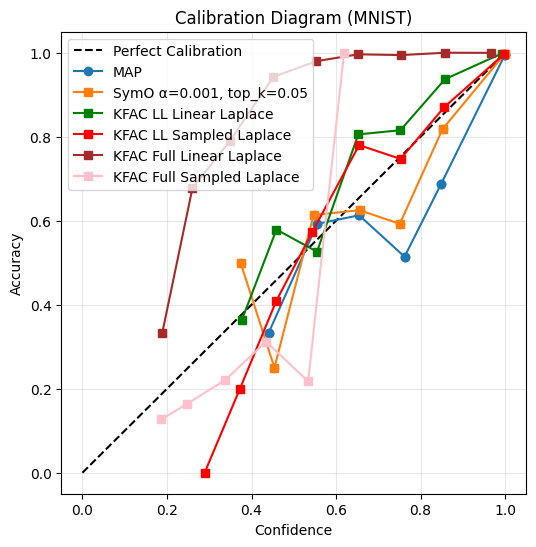

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from mnist import get_mnist_loaders
from LeNet import LeNet

# -------------------------------
# Calibration plotting function
# -------------------------------
def plot_calib_overlay_torch(map_params, posterior_samples, model, x_test, y_test, M=10, labels=None, device='cpu'):
    """
    Calibration diagram (reliability plot) for MAP and posterior in PyTorch.

    Args:
        map_params: state_dict of MAP model
        posterior_samples: list of state_dicts for posterior samples
        model: torch.nn.Module class (uninitialized)
        x_test: torch.Tensor (N,C,H,W)
        y_test: torch.Tensor (N,) integer labels
        M: number of bins
        labels: list of labels for legend
        device: 'cpu' or 'cuda'
    """

    x_test = x_test.to(device)
    y_true = y_test.cpu().numpy()

    # -------- MAP --------
    model.load_state_dict(map_params)
    model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x_test)
        probs = F.softmax(logits, dim=1).cpu().numpy()

    confs = np.max(probs, axis=1)
    preds = np.argmax(probs, axis=1)

    bins = np.linspace(0,1,M+1)
    conf_idxs = np.digitize(confs, bins, right=True) - 1
    conf_idxs = np.clip(conf_idxs, 0, M-1)

    accs_bin = []
    confs_bin = []
    for i in range(M):
        mask = (conf_idxs == i)
        if np.any(mask):
            acc_bin = np.mean(preds[mask]==y_true[mask])
            conf_bin = np.mean(confs[mask])
        else:
            acc_bin = np.nan
            conf_bin = (bins[i]+bins[i+1])/2
        accs_bin.append(acc_bin)
        confs_bin.append(conf_bin)

    plt.plot(confs_bin, accs_bin, marker='o', label=labels[0] if labels else 'MAP')
    plt.scatter(confs_bin, accs_bin)

    # -------- Posterior --------
    probs_stack = []
    for state_dict in posterior_samples:
        model.load_state_dict(state_dict)
        model.eval()
        with torch.no_grad():
            logits_post = model(x_test)
            probs_post = F.softmax(logits_post, dim=1).cpu().numpy()
            probs_stack.append(probs_post)

    probs_stack = np.stack(probs_stack, axis=0)  # (num_samples, N, C)
    probs_mean = np.mean(probs_stack, axis=0)    # (N, C)

    confs_post = np.max(probs_mean, axis=1)
    preds_post = np.argmax(probs_mean, axis=1)

    conf_idxs_post = np.digitize(confs_post, bins, right=True) - 1
    conf_idxs_post = np.clip(conf_idxs_post, 0, M-1)

    accs_bin_post = []
    confs_bin_post = []
    for i in range(M):
        mask = (conf_idxs_post == i)
        if np.any(mask):
            acc_bin = np.mean(preds_post[mask]==y_true[mask])
            conf_bin = np.mean(confs_post[mask])
        else:
            acc_bin = np.nan
            conf_bin = (bins[i]+bins[i+1])/2
        accs_bin_post.append(acc_bin)
        confs_bin_post.append(conf_bin)

    plt.plot(confs_bin_post, accs_bin_post, marker='s', label=labels[1] if labels else 'Posterior')
    plt.scatter(confs_bin_post, accs_bin_post)




# -------------------------------
# Load data and models
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MNIST validation data
train_loader, test_loader = get_mnist_loaders(test_batch_size=10000)
x_val, y_val = next(iter(test_loader))
x_val, y_val = x_val.to(device), y_val.to(device)

# Initialize model
model = LeNet(activation='tanh').to(device)

# Load MAP parameters
map_params = torch.load('adam_map.pth', map_location=device)

# Load posterior samples (best alpha=0.0001, top_k=0.05)
posterior_samples = [
    torch.load(f'adam_samples/top_k0.05alpha_0.001_samp{i+1}.pth', map_location=device)
    for i in range(10)
]

# -------------------------------
# Plot calibration
# -------------------------------
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'--', color='black', label='Perfect Calibration')

plot_calib_overlay_torch(
    map_params=map_params,
    posterior_samples=posterior_samples,
    model=model,
    x_test=x_val,
    y_test=y_val,
    labels=['MAP','SymO α=0.001, top_k=0.05'],
    device=device
)

redux_utils.load_and_plot('laplace_redux_dicts/redux_last_layer_kron_linear_prior1.0.json','KFAC LL Linear Laplace',color='green')
redux_utils.load_and_plot('laplace_redux_dicts/redux_last_layer_kron_samp_prior1.0.json','KFAC LL Sampled Laplace',color='red')
redux_utils.load_and_plot('laplace_redux_dicts/redux_all_kron_linear_prior1.0.json','KFAC Full Linear Laplace',color='brown')
redux_utils.load_and_plot('laplace_redux_dicts/redux_all_kron_samp_prior1.0.json','KFAC Full Sampled Laplace',color='pink')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title('Calibration Diagram (MNIST)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()